In [33]:
filename = input("Enter the filename (including extension) of the OPDx file: ")
grid_rows = int(input("Enter the number of rows for the grid (e.g., 8): "))
grid_cols = int(input("Enter the number of columns for the grid (e.g., 8): "))

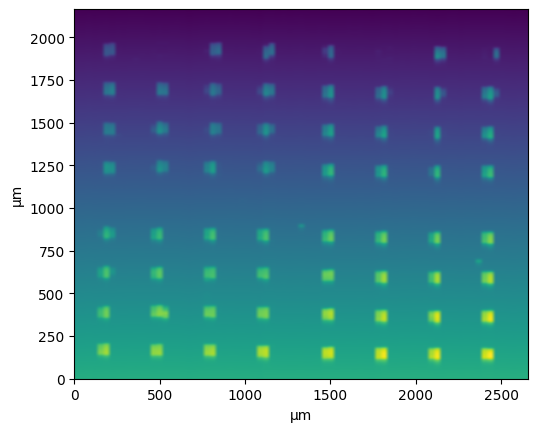

In [34]:
from OPDx_read.reader import DektakLoad
loader=DektakLoad(filename)
x,y,z=loader.get_data_2D()
dataname = filename.rsplit('.', 1)[0]

In [35]:
z.shape

(901, 77)

## 3D Plot

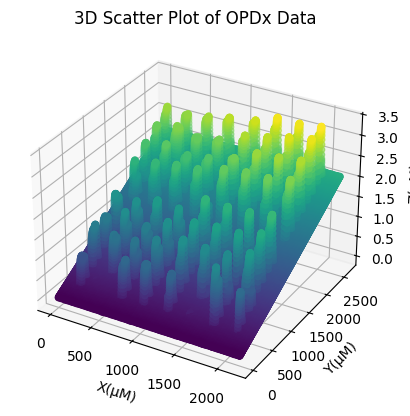

In [36]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
x_mesh, y_mesh = np.meshgrid(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Flatten the x_mesh, y_mesh, and z arrays for the scatter plot
x_flat = x_mesh.flatten()
y_flat = y_mesh.flatten()
z_flat = z.flatten()

ax.scatter(x_flat, y_flat, z_flat, c=z_flat, cmap='viridis', marker='o')

ax.set_xlabel('X(μM)')
ax.set_ylabel('Y(μM)')
ax.set_zlabel('Z(μM)')
ax.set_title('3D Scatter Plot of OPDx Data')

plt.show()

## Generate Histograms and Background Mask


In [37]:
# Group by 10 lines
num_rows = z.shape[0]
group_size = 10

# Number of groups
num_groups = int(np.ceil(num_rows / group_size))

# List to hold threshold for each group
group_background_thresholds = []

# Loop through the z array in steps of group_size:
for i in range(num_groups):
    # Select group from z
    start_row = i * group_size
    end_row = min((i + 1) * group_size, num_rows)
    current_group_data = z[start_row:end_row, :]

    combined_heights = current_group_data.flatten()

    # Calculate threshold
    percentile_value = np.percentile(combined_heights, 45)
    group_background_thresholds.append(percentile_value)


In [38]:
group_background_masks_rows = []

# Apply threshold to each row
for row_idx in range(num_rows):
    group_index = row_idx // group_size

    # Get the corresponding group threshold
    threshold = group_background_thresholds[group_index]

    # Get the current row data from z
    row_data = z[row_idx, :]

    # Create a boolean mask: True if pixel height <= threshold
    row_mask = row_data <= threshold
    group_background_masks_rows.append(row_mask)

# Convert the list of row masks into a single numpy boolean array
group_background_mask = np.array(group_background_masks_rows)

## Visualize Background Mask from Thresholded Groups

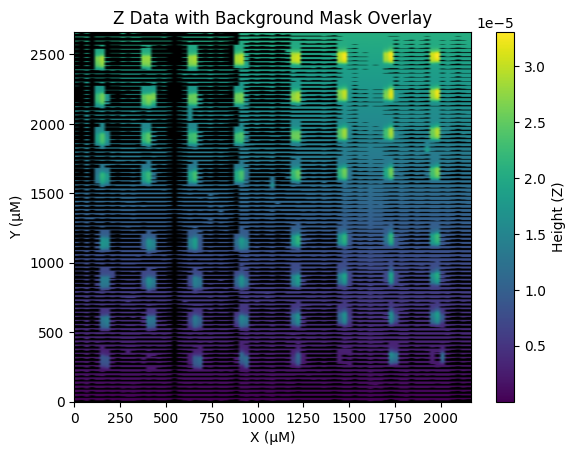

In [39]:
from matplotlib.colors import ListedColormap

plt.figure()
plt.imshow(z, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar(label='Height (Z)')

colors = ['black']
custom_cmap = ListedColormap(colors)
masked_z_background = np.ma.masked_array(z, mask=~group_background_mask) # Mask where background_mask is False

plt.imshow(masked_z_background, cmap=custom_cmap, origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.title('Z Data with Background Mask Overlay')
plt.xlabel('X (μM)')
plt.ylabel('Y (μM)')
plt.show()

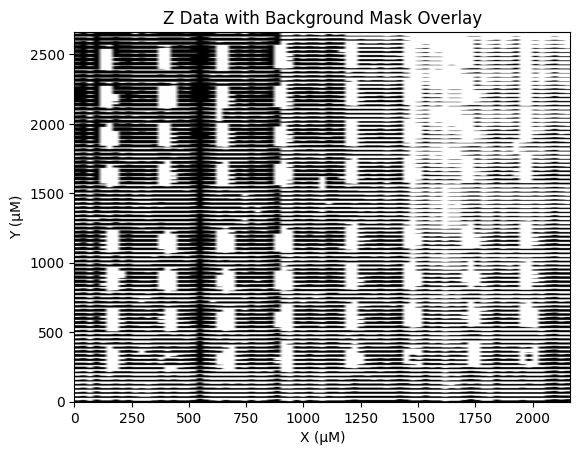

In [40]:
plt.figure()
colors = ['black']
custom_cmap = ListedColormap(colors)

masked_z_background = np.ma.masked_array(z, mask=~group_background_mask) # Mask where background_mask is False
plt.imshow(masked_z_background, cmap=custom_cmap, origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.title('Z Data with Background Mask Overlay')
plt.xlabel('X (μM)')
plt.ylabel('Y (μM)')
plt.show()

## Least Square Fit Plane using Background Mask and Level data

In [41]:
x_background = x_mesh[group_background_mask]
y_background = y_mesh[group_background_mask]
z_actual_background = z[group_background_mask]

A_background = np.c_[x_background, y_background, np.ones(x_background.shape[0])]

# 2. Perform a least squares fit
coeffs_background, _, _, _ = np.linalg.lstsq(A_background, z_actual_background, rcond=None)

# Store the coefficients and intercept
reg_coef_background = coeffs_background[:2]
reg_intercept_background = coeffs_background[2]

# Calculate Z values from estimated coefficients
z_predicted_background_new_plane = reg_intercept_background + reg_coef_background[0] * x_background + reg_coef_background[1] * y_background

## Visualize Estimated Plane and Background Points

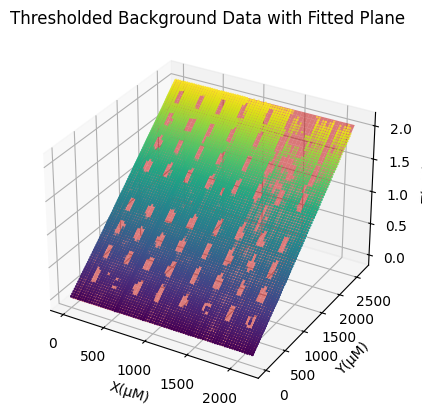

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_background, y_background, z_actual_background, c=z_actual_background, cmap='viridis', marker='o', label='Background Data', s=0.5)

x_surf_background, y_surf_background = np.meshgrid(np.linspace(x_background.min(), x_background.max(), 50), 
                                                   np.linspace(y_background.min(), y_background.max(), 50))

z_surf_background = reg_intercept_background + reg_coef_background[0] * x_surf_background + reg_coef_background[1] * y_surf_background

ax.plot_surface(x_surf_background, y_surf_background, z_surf_background, color='red', alpha=0.5, label='Fitted Background Plane')
ax.set_xlabel('X(μM)')
ax.set_ylabel('Y(μM)')
ax.set_zlabel('Z(μM)')
ax.set_title('Thresholded Background Data with Fitted Plane')

plt.show()

# Create New Background Mask by Calculating Difference between Estimated Plane and Actual Height Data

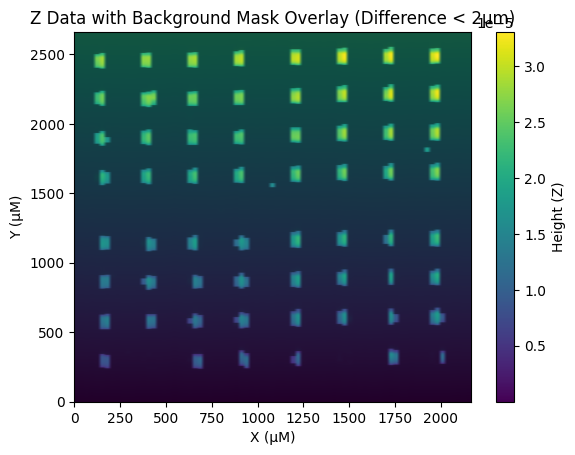

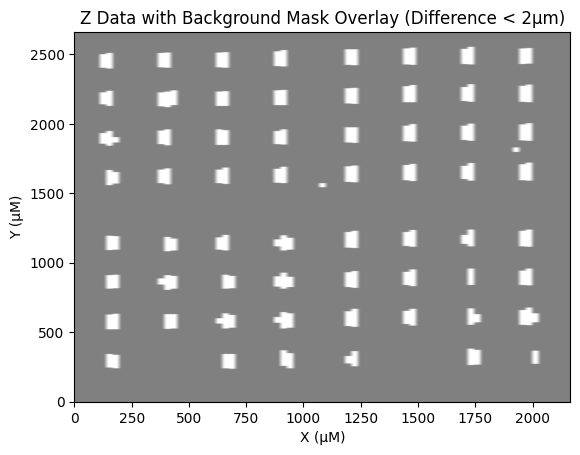

In [43]:
# Calculate predicted Z-values for the entire data (x_mesh, y_mesh)
# using the plane coefficients derived from previous background data
z_predicted_full = reg_intercept_background + reg_coef_background[0] * x_mesh + reg_coef_background[1] * y_mesh

# Calculate difference
difference_z = np.abs(z - z_predicted_full)

# Refine background mask where the difference is less than 2µm
new_background_mask = difference_z < 2e-6

plt.figure()
plt.imshow(z, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar(label='Height (Z)')
masked_z_new_background = np.ma.masked_array(z, mask=~new_background_mask) # Mask where new_background_mask is False
plt.imshow(masked_z_new_background, cmap=custom_cmap, origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()], alpha=0.5)

plt.title('Z Data with Background Mask Overlay (Difference < 2µm)')
plt.xlabel('X (μM)')
plt.ylabel('Y (μM)')
plt.show()


plt.figure()
masked_z_new_background = np.ma.masked_array(z, mask=~new_background_mask) # Mask where new_background_mask is False
plt.imshow(masked_z_new_background, cmap=custom_cmap, origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()], alpha=0.5)

plt.title('Z Data with Background Mask Overlay (Difference < 2µm)')
plt.xlabel('X (μM)')
plt.ylabel('Y (μM)')
plt.show()

## Connected Component Analysis

Number of detected components (including background): 65


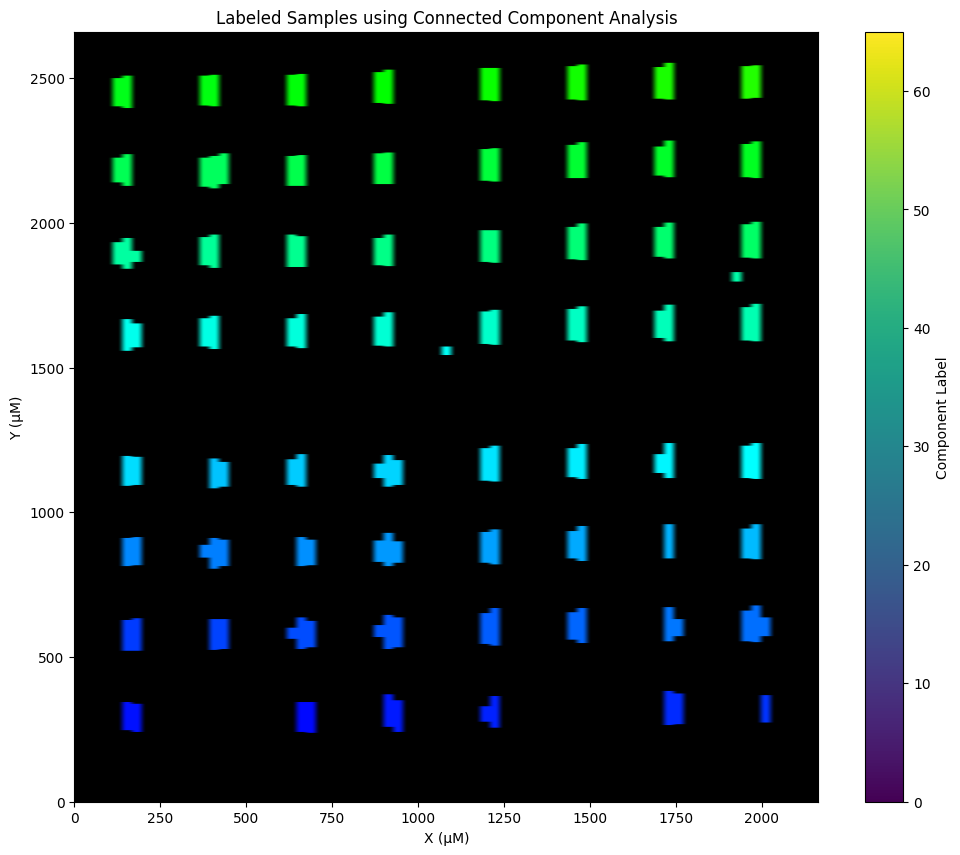

In [44]:
import cv2

# Prepare mask for OpenCV connectedComponentsWithStats
connectivity = 4
output_mask_cv = (~new_background_mask).astype(np.uint8) * 255

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(output_mask_cv, connectivity, cv2.CV_32S)

print(f"Number of detected components (including background): {num_labels}")

# Create a colormap for visualization
label_hue = np.uint8(labels)
blank_ch = 255*np.ones_like(label_hue)
labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])

# Convert to BGR for OpenCV display (or RGB for matplotlib)
labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)

# Set background (label 0) to black
labeled_img[labels == 0] = 0

# Visualize the labeled components
plt.figure(figsize=(12, 10))
plt.imshow(labeled_img, origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.title('Labeled Samples using Connected Component Analysis')
plt.xlabel('X (μM)')
plt.ylabel('Y (μM)')
plt.colorbar(label='Component Label')
plt.clim(0,num_labels)
plt.show()

## Filter out components with small area

Number of components after filtering (including background): 63


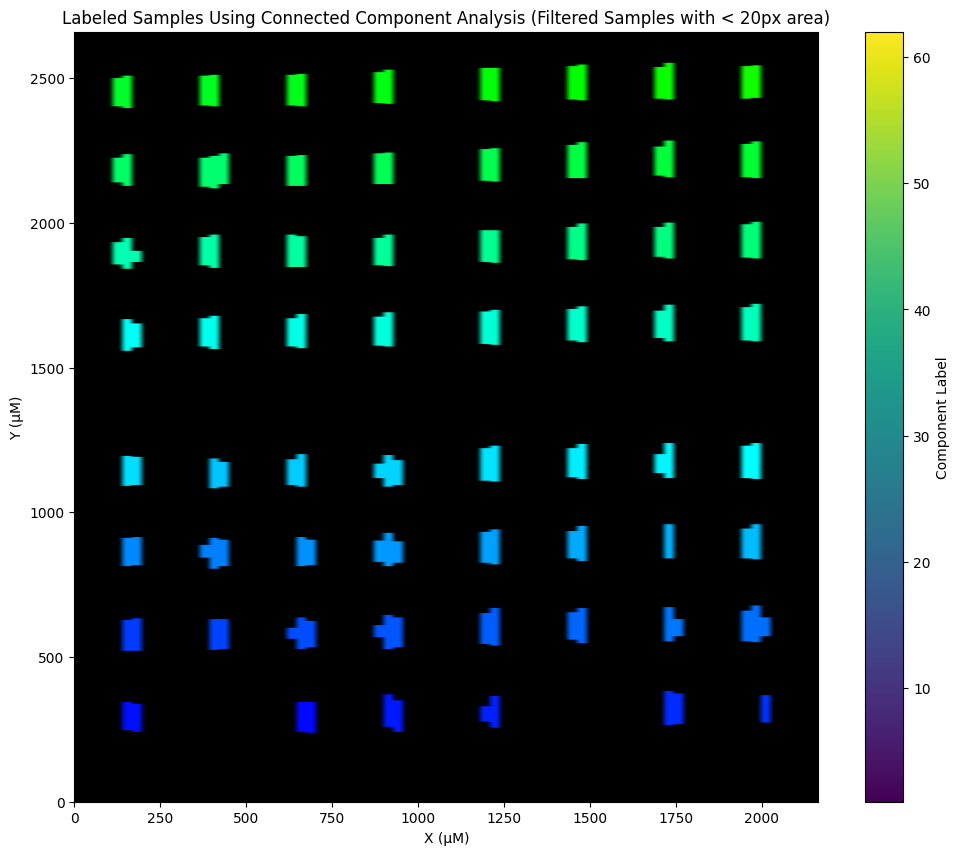

In [45]:
min_area_threshold = 15

filtered_labels = np.zeros_like(labels, dtype=np.int32)

# Initialize lists to store filtered stats and centroids
filtered_stats = [stats[0]]
filtered_centroids = [centroids[0]]

# Iterate through each component (starting from label 1, as 0 is background)
current_label = 1
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    if area >= min_area_threshold:
        filtered_labels[labels == i] = current_label # Assign new sequential label
        filtered_stats.append(stats[i])
        filtered_centroids.append(centroids[i])
        current_label += 1

# Convert lists back to numpy arrays
filtered_stats = np.array(filtered_stats)
filtered_centroids = np.array(filtered_centroids)

# Get the new number of labels
new_num_labels = len(filtered_stats)

print(f"Number of components after filtering (including background): {new_num_labels}")

max_filtered_label = np.max(filtered_labels) if new_num_labels > 1 else 0
if max_filtered_label > 0:
    label_hue_filtered = np.uint8(filtered_labels)
else:
    label_hue_filtered = np.zeros_like(filtered_labels, dtype=np.uint8)

blank_ch_filtered = 255 * np.ones_like(label_hue_filtered)
labeled_img_filtered = cv2.merge([label_hue_filtered, blank_ch_filtered, blank_ch_filtered])
labeled_img_filtered = cv2.cvtColor(labeled_img_filtered, cv2.COLOR_HSV2BGR)
labeled_img_filtered[filtered_labels == 0] = 0 # Set background (label 0) to black

plt.figure(figsize=(12, 10))
plt.imshow(labeled_img_filtered, origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.title(f'Labeled Samples Using Connected Component Analysis (Filtered Samples with < 20px area)')
plt.xlabel('X (μM)')
plt.ylabel('Y (μM)')
plt.colorbar(label='Component Label')
plt.clim(1, max_filtered_label)
plt.show()

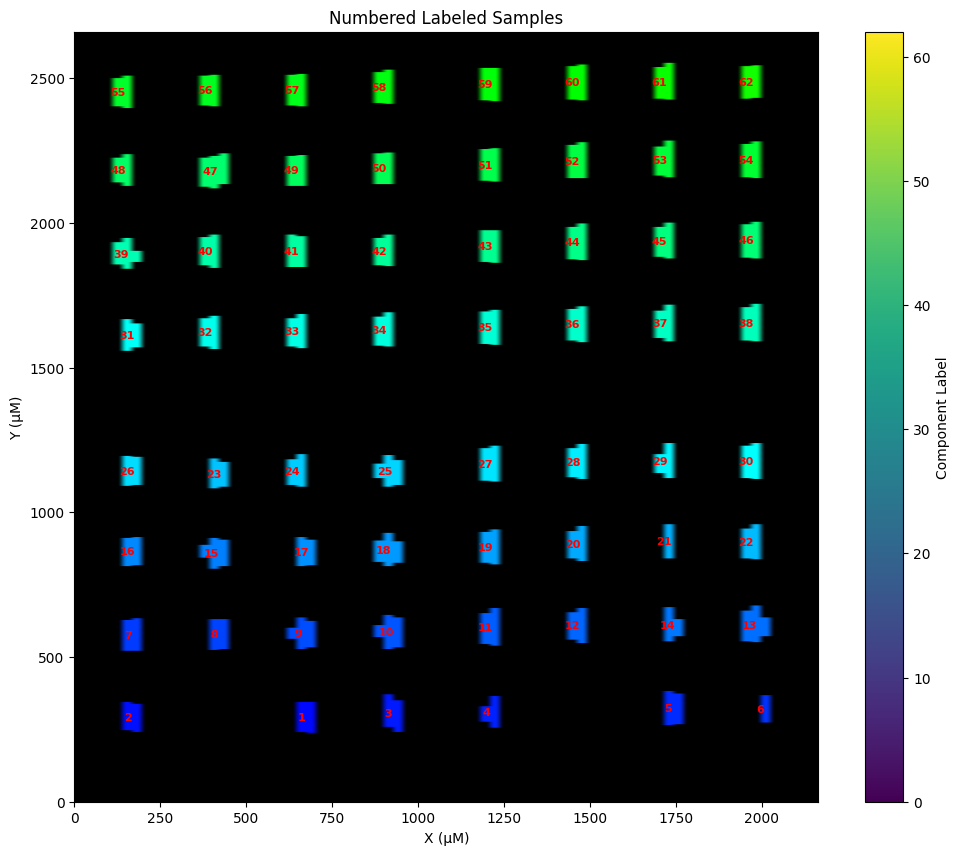

In [46]:
plt.figure(figsize=(12, 10))
plt.imshow(labeled_img_filtered, origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.title(f'Numbered Labeled Samples')
plt.xlabel('X (μM)')
plt.ylabel('Y (μM)')

# Add labels for each component at its centroid
for i in range(1, len(filtered_centroids)): # Start from 1 to skip background
    centroid_x_px = filtered_centroids[i, 0]
    centroid_y_px = filtered_centroids[i, 1]
    # Convert pixel coordinates to data coordinates for plotting
    # Note: X-coordinates directly correspond, Y-coordinates need scaling/offset
    # For simplicity, assuming a direct mapping for now, adjust if visualization is off
    x_data_coord = np.interp(centroid_x_px, [0, filtered_labels.shape[1]], [x.min(), x.max()])
    y_data_coord = np.interp(centroid_y_px, [0, filtered_labels.shape[0]], [y.min(), y.max()])

    plt.text(x_data_coord, y_data_coord, str(i), color='red', fontsize=8, ha='center', va='center', weight='bold')

plt.colorbar(label='Component Label')
plt.clim(0, max_filtered_label)
plt.show()

# Reorder Components

Total components detected for mapping: 62


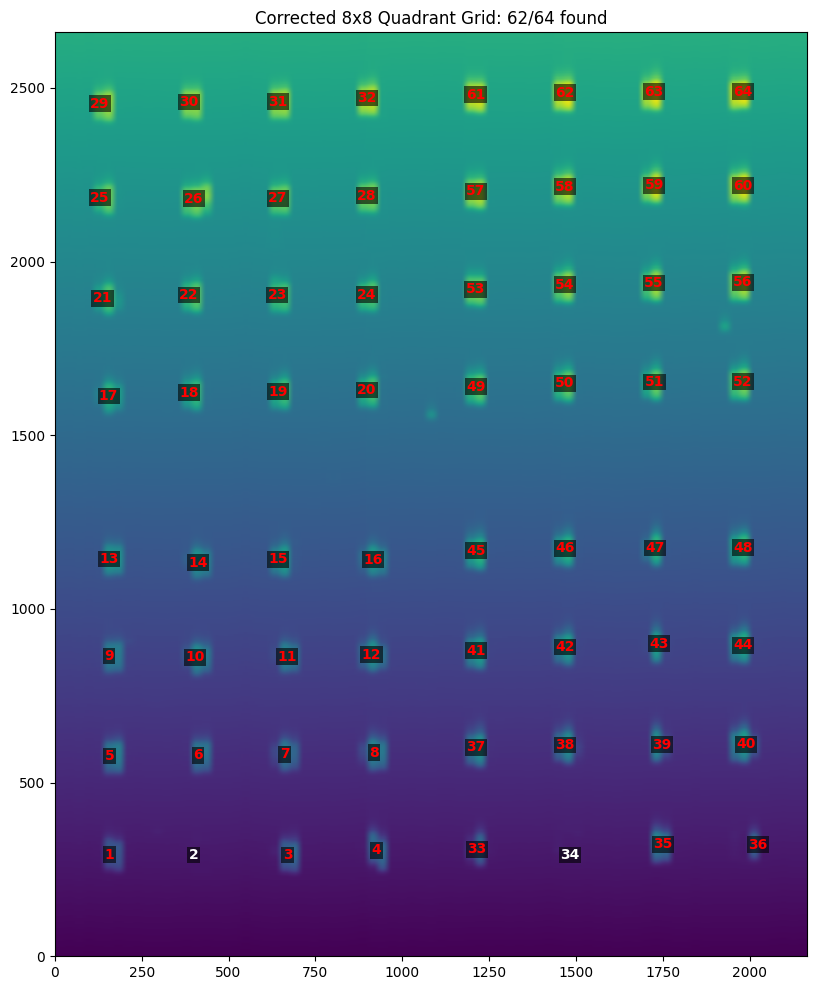

Final Missing Count: 2


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

# 1. Re-extract components from the original connected components to ensure a clean state
# label 0 is background. Use stats to filter by area as we did before.
min_area = 15
valid_comp_indices = [i for i in range(1, num_labels) if stats[i, cv2.CC_STAT_AREA] >= min_area]
comp_centroids_raw = centroids[valid_comp_indices]
comp_stats_raw = stats[valid_comp_indices]

print(f"Total components detected for mapping: {len(comp_centroids_raw)}")

# 2. Define 8x8 Grid centers based on the bounds of these detections
unique_x = np.linspace(comp_centroids_raw[:, 0].min(), comp_centroids_raw[:, 0].max(), 8)
unique_y = np.linspace(comp_centroids_raw[:, 1].min(), comp_centroids_raw[:, 1].max(), 8)

# 3. Create theoretical slots in quadrant order (BL, TL, BR, TR)
# Quadrant ranges: 0-3 and 4-7
quadrant_ranges = [
    ((0, 4), (0, 4)), # Bottom-Left
    ((0, 4), (4, 8)), # Top-Left
    ((4, 8), (0, 4)), # Bottom-Right
    ((4, 8), (4, 8))  # Top-Right
]

theoretical_slots = []
for col_range, row_range in quadrant_ranges:
    # Within quadrant: Sequential on each row (L-R), Bottom to Top
    for r in range(row_range[0], row_range[1]):
        for c in range(col_range[0], col_range[1]):
            theoretical_slots.append((unique_x[c], unique_y[r]))
theoretical_slots = np.array(theoretical_slots)

# 4. Global 1-to-1 Mapping
dist_matrix = np.zeros((len(comp_centroids_raw), len(theoretical_slots)))
for i in range(len(comp_centroids_raw)):
    for j in range(len(theoretical_slots)):
        dist_matrix[i, j] = np.linalg.norm(comp_centroids_raw[i] - theoretical_slots[j])

det_indices, slot_indices = linear_sum_assignment(dist_matrix)

slot_to_det_map = {slot_idx + 1: det_idx for det_idx, slot_idx in zip(det_indices, slot_indices)}

# 5. Build final 65-element arrays
final_centroids = np.zeros((65, 2))
final_stats = np.zeros((65, 5), dtype=int)
final_centroids[0] = centroids[0]
final_stats[0] = stats[0]

for slot_id in range(1, 65):
    if slot_id in slot_to_det_map:
        d_idx = slot_to_det_map[slot_id]
        final_centroids[slot_id] = comp_centroids_raw[d_idx]
        final_stats[slot_id] = comp_stats_raw[d_idx]
    else:
        final_centroids[slot_id] = theoretical_slots[slot_id - 1]
        final_stats[slot_id] = 0

# 6. Visualization
plt.figure(figsize=(14, 12))
plt.imshow(z, cmap='viridis', origin='lower', extent=[x.min(), x.max(), y.min(), y.max()], alpha=1)

x_scale = (x.max() - x.min()) / (z.shape[1] - 1)
y_scale = (y.max() - y.min()) / (z.shape[0] - 1)

missing_count = 0
for i in range(1, 65):
    cx_px, cy_px = final_centroids[i]
    cx_data = x.min() + cx_px * x_scale
    cy_data = y.min() + cy_px * y_scale
    
    is_missing = np.all(final_stats[i] == 0)
    if is_missing: missing_count += 1
    text_color = 'white' if is_missing else 'red'
    
    plt.text(cx_data, cy_data, str(i), color=text_color, fontsize=10, weight='bold', 
             ha='center', va='center', bbox=dict(facecolor='black', alpha=0.6, lw=0, pad=1))

plt.title(f'Corrected 8x8 Quadrant Grid: {64-missing_count}/64 found')
plt.show()

print(f"Final Missing Count: {missing_count}")

# Update globals
filtered_centroids = final_centroids
filtered_stats = final_stats

In [48]:
import pandas as pd

# Setup bounding box
box_w_px = 15
box_h_px = 80

# Prepare list for results
sample_height_results = []

# 2. Iterate through slots 1-64
for i in range(1, 65):
    # Check if component exists (stats not zero)
    if np.all(final_stats[i] == 0):
        sample_height_results.append({
        'component_id': i,
        'centroid_x': 'NoVal',
        'centroid_y': 'NoVal',
        'top': 'NoVal',
        'bottom': 'NoVal',
        'difference': 'NoVal',
    })
        continue
        
    cx_px, cy_px = final_centroids[i]
    
    # Define crop boundaries (ensure within image limits)
    y_start = int(max(0, cy_px - box_h_px // 2))
    y_end = int(min(z.shape[0], cy_px + box_h_px // 2))
    x_start = int(max(0, cx_px - box_w_px // 2))
    x_end = int(min(z.shape[1], cx_px + box_w_px // 2))
    

    # Extract local data in region
    x_mesh_local = x_mesh[y_start:y_end, x_start:x_end]
    y_mesh_local = y_mesh[y_start:y_end, x_start:x_end]
    z_local = z[y_start:y_end, x_start:x_end]
    new_background_mask_local = new_background_mask[y_start:y_end, x_start:x_end]

    # Extract local background pixels for plane fitting
    x_bg_for_fit = x_mesh_local[new_background_mask_local]
    y_bg_for_fit = y_mesh_local[new_background_mask_local]
    z_bg_for_fit = z_local[new_background_mask_local]

    # Determine plane coefficients for local region
    local_reg_coef = reg_coef_background  # Fallback to global
    local_reg_intercept = reg_intercept_background # Fallback to global

    # Only fit a local plane if enough background points (min 3 for a plane)
    if len(x_bg_for_fit) >= 3:
        A_local_bg = np.c_[x_bg_for_fit, y_bg_for_fit, np.ones(x_bg_for_fit.shape[0])]
        try:
            coeffs_local, _, _, _ = np.linalg.lstsq(A_local_bg, z_bg_for_fit, rcond=None)
            local_reg_coef = coeffs_local[:2]
            local_reg_intercept = coeffs_local[2]
        except np.linalg.LinAlgError:
            print(f"Warning: Local plane fit failed for component {i} (singular matrix). Using global plane.")
    else:
        print(f"Warning: Not enough background points ({len(x_bg_for_fit)}) for local plane fit for component {i}. Using global plane.")
    
    # Calculate predicted Z-values for the entire square using the local background plane equation, then subtract to level data
    z_predicted_local_plane = local_reg_intercept + local_reg_coef[0] * x_mesh_local + local_reg_coef[1] * y_mesh_local
    z_leveled_local = z_local - z_predicted_local_plane

    # Find the index of the maximum Z-height within the local region
    max_z_idx_flat = np.argmax(z_leveled_local)
    max_z_row, max_z_col = np.unravel_index(max_z_idx_flat, z_leveled_local.shape)

    # (x,y) coordinates at the location of max Z
    x_at_max_z = x_mesh_local[max_z_row, max_z_col]
    y_at_max_z = y_mesh_local[max_z_row, max_z_col]

    # Calculate predicted Z-value at the exact (x,y) of max Z
    z_predicted_at_max_z_idx = local_reg_intercept + local_reg_coef[0] * x_at_max_z + local_reg_coef[1] * y_at_max_z

    # Calculate the max actual Z-height within the local region
    max_z_in_local_region = z_leveled_local.max()

    # Calculate the height of the sample (feature height above local plane at that specific point)
    # Convert to micrometers
    sample_height_from_exact_point = (max_z_in_local_region - z_predicted_at_max_z_idx) * 1e6

    sample_height_results.append({
        'component_id': i,
        'centroid_x': cx_px,
        'centroid_y': cy_px,
        'top': max_z_in_local_region * 1e6,
        'bottom': z_predicted_at_max_z_idx * 1e6,
        'difference': sample_height_from_exact_point,
    })

# 6. Create DataFrame and Export
df_heights = pd.DataFrame(sample_height_results)

# Define the filename for the CSV file
csv_output = f'sample_heights_reordered_{dataname[0]}{dataname[2]}.csv'
df_heights.to_csv(csv_output, index=False)

print(f"Calculation complete. Results saved to {csv_output}")
display(df_heights)

Calculation complete. Results saved to sample_heights_reordered_P3.csv


,component_id,centroid_x,centroid_y,top,bottom,difference
0,1,5.5,99.0,6.438153,2.347333,4.09082
1,2,NoVal,NoVal,NoVal,NoVal,NoVal
2,3,23.507042,98.746479,8.818269,2.324437,6.493832
3,4,32.493333,103.293333,9.255687,2.324221,6.931466
4,5,5.513514,195.013514,9.71701,4.443574,5.273436
...,...,...,...,...,...,...
59,60,69.52439,750.52439,14.848189,17.238461,-2.390272
60,61,42.506494,839.246753,11.47567,19.111259,-7.635589
61,62,51.518519,841.259259,13.165846,19.301387,-6.135541
62,63,60.5375,842.075,12.974541,19.387368,-6.412827
